# Historical Network Analysis of Virginia City (1880)

## Data Exploration

This notebook loads and explores the 1880 Virginia City census dataset to understand the demographics and community structure of Virginia City, Montana.

## Project Overview

This notebook explores demographic and occupational characteristics of Virginia City, Montana, using historical 1880 census records. The analysis includes data cleaning, exploratory data analysis, and visualizations that provide insight into the town's population structure and serve as the foundation for subsequent network analysis.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the Dataset

In [13]:
df = pd.read_excel("Virginia City Census Dataset 1880.xlsx")

## Preview the Dataset

In [14]:
df.head()

,Name,Sex,Age,Birth Year (Estimated),Birthplace,Marital Status,Occupation,Race,Relationship to Head of Household,Father's Birthplace,Mother's Birthplace,Person Number,Sheet Letter,Sheet Number,Volume
0,Joseph Hiuchman,Male,34 years,1846,"Indiana, United States",Married,Druggist,White,Self,"Virginia, United States","Indiana, United States",0,D,385,1.0
1,Irene Hiuchman,Female,34 years,1846,"Indiana, United States",Married,Keeping House,White,Wife,"Indiana, United States","Indiana, United States",1,D,385,1.0
2,Emma Hiuchman,Female,6 years,1874,"Missouri, United States",Single,NaN,White,Daughter,"Indiana, United States","Indiana, United States",2,D,385,1.0
3,Samuel Crockett,Male,47 years,1833,"Tennessee, United States",Married,Harness Maker,White,Self,Scotland,Germany,0,D,385,1.0
4,Serafine Crockett,Female,40 years,1840,"Tennessee, United States",Married,Keeping House,White,Wife,"North Carolina, United States","Tennessee, United States",1,D,385,1.0


## Dataset Dimensions

In [15]:
df.shape

(625, 15)

## Dataset Information

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Name                               625 non-null    object 
 1   Sex                                625 non-null    object 
 2   Age                                625 non-null    object 
 3   Birth Year (Estimated)             625 non-null    int64  
 4   Birthplace                         625 non-null    object 
 5   Marital Status                     623 non-null    object 
 6   Occupation                         471 non-null    object 
 7   Race                               625 non-null    object 
 8   Relationship to Head of Household  625 non-null    object 
 9   Father's Birthplace                625 non-null    object 
 10  Mother's Birthplace                624 non-null    object 
 11  Person Number                      625 non-null    int64  

## Missing Values

In [17]:
df.isna().sum()

Name                                   0
Sex                                    0
Age                                    0
Birth Year (Estimated)                 0
Birthplace                             0
Marital Status                         2
Occupation                           154
Race                                   0
Relationship to Head of Household      0
Father's Birthplace                    0
Mother's Birthplace                    1
Person Number                          0
Sheet Letter                           0
Sheet Number                           0
Volume                                 2
dtype: int64

## Clean the Age Column

In [24]:
# Data contains inconsistent age formats
# Convert everything to text first
df["Age_Clean"] = df["Age"].astype(str)

# Remove the word "years"
df["Age_Clean"] = df["Age_Clean"].str.replace(" years", "", regex=False)

# Convert to numbers
df["Age_Clean"] = pd.to_numeric(df["Age_Clean"], errors="coerce")

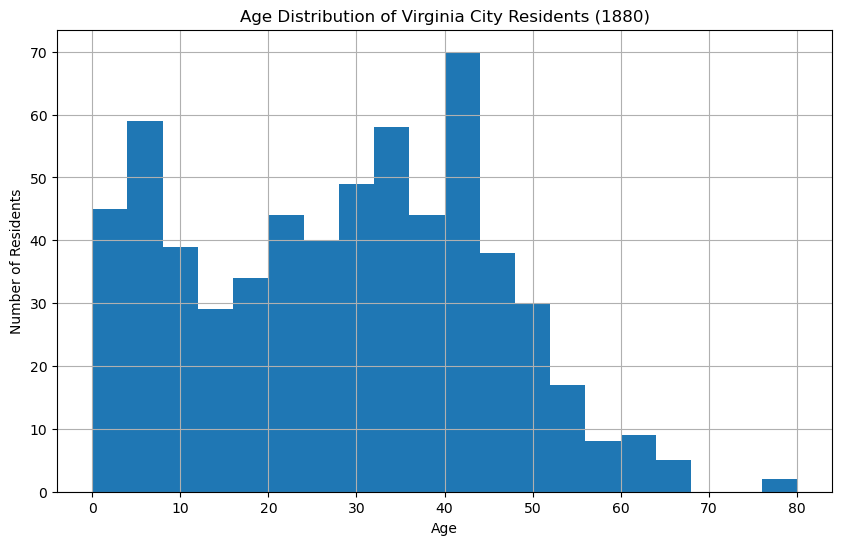

In [25]:
df["Age_Clean"].hist(bins=20, figsize=(10,6))

plt.title("Age Distribution of Virginia City Residents (1880)")
plt.xlabel("Age")
plt.ylabel("Number of Residents")

plt.show()

### Key Insight

The age distribution indicates that Virginia City was primarily composed of working-age adults, reflecting its role as an active mining community during the late nineteenth century. While children and older adults were also present, the population was concentrated among individuals most likely to participate in the local workforce.


## Occupation Analysis

In [38]:
df["Occupation"].value_counts(dropna=False)

Occupation
NaN                   154
Keeping House          92
Placer Miner           34
Cook                   19
Laborer                19
                     ... 
Stationer               1
Servant                 1
Works In Shop           1
Stable Keeper           1
Old & Silver Miner      1
Name: count, Length: 119, dtype: int64

In [19]:
df["Occupation"].value_counts().head(20)

Occupation
Keeping House        92
Placer Miner         34
Laborer              19
Cook                 19
Teamster             17
Clerk In Store       15
Stays At Home        14
Quartz Miner         13
Attends School       10
Gambler               9
Keeps China Store     8
Grocer                8
Butcher               8
Blacksmith            7
Miner Placer          6
Goes To School        6
Saloon Keeper         6
Carpenter             5
Tailor                5
Stock Herder          5
Name: count, dtype: int64

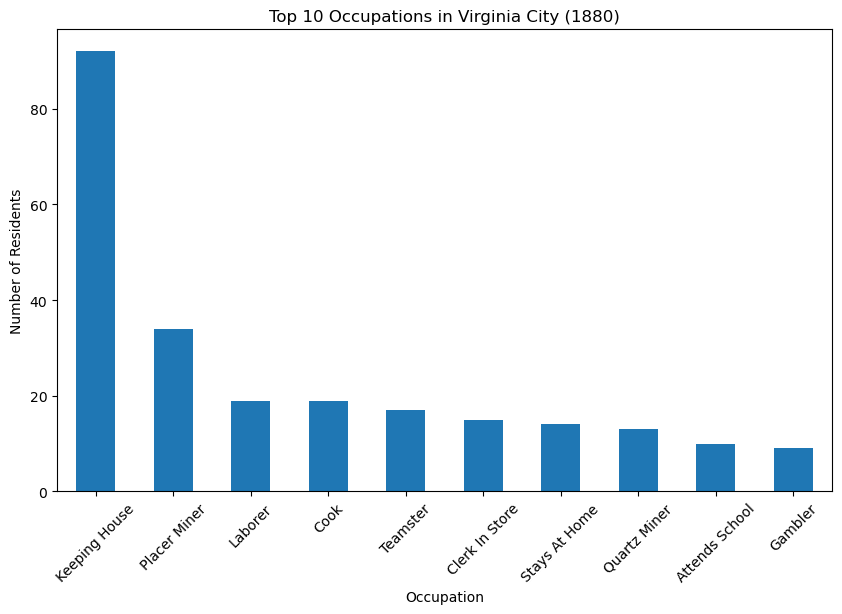

In [20]:
top_occupations = df["Occupation"].value_counts().head(10)

top_occupations.plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Occupations in Virginia City (1880)")
plt.xlabel("Occupation")
plt.ylabel("Number of Residents")

plt.xticks(rotation=45)

plt.show()

### Key Insight

Mining-related occupations dominated the workforce, reflecting Virginia City's economy during the mining boom. However, the presence of merchants, physicians, teachers, hotel keepers, and other occupations demonstrates that the town had developed into a permanent community rather than a temporary mining camp.

## Occupation Analysis



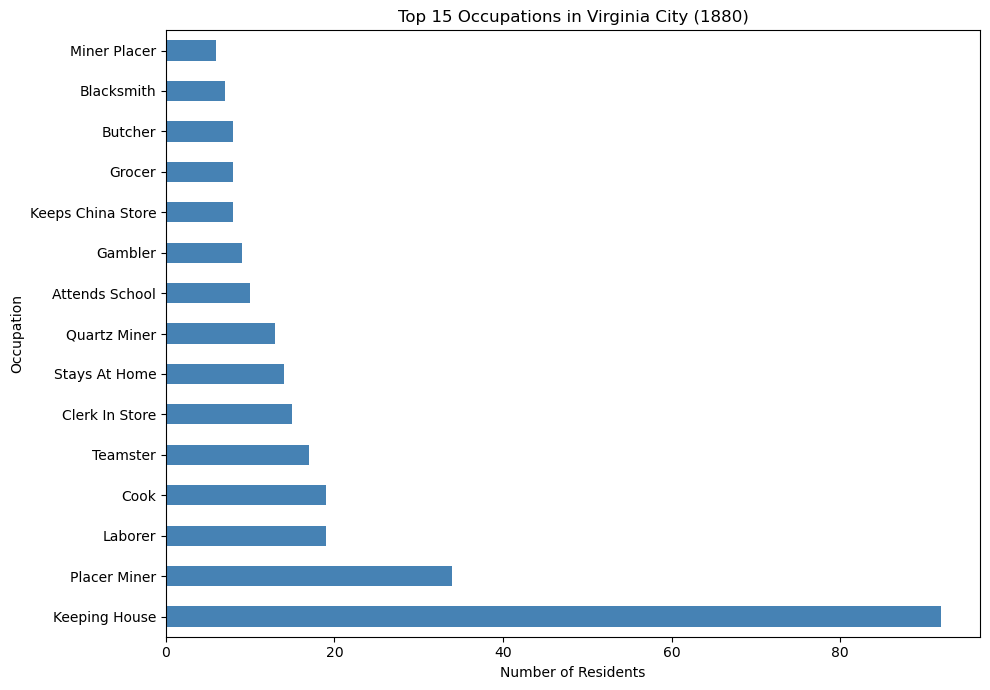

In [27]:
top_occupations.plot(
    kind="barh",
    figsize=(10,7),
    color="steelblue"
)

plt.title("Top 15 Occupations in Virginia City (1880)")
plt.xlabel("Number of Residents")
plt.ylabel("Occupation")

plt.tight_layout()
plt.show()

### Key Insight

The most common occupations reveal the industries that supported everyday life in Virginia City. Although mining remained the primary economic activity, a variety of supporting occupations contributed to the town's long-term stability and growth.


## Birthplace Analysis

In [28]:
df["Birthplace"].value_counts().head(15)

Birthplace
Montana, United States          149
China                            89
Missouri, United States          47
Illinois, United States          33
New York, United States          29
Germany                          29
Ohio, United States              25
England                          25
Pennsylvania, United States      24
Virginia, United States          18
Iowa, United States              15
Indiana, United States           13
Massachusetts, United States     12
Ireland                          12
Kentucky, United States          11
Name: count, dtype: int64

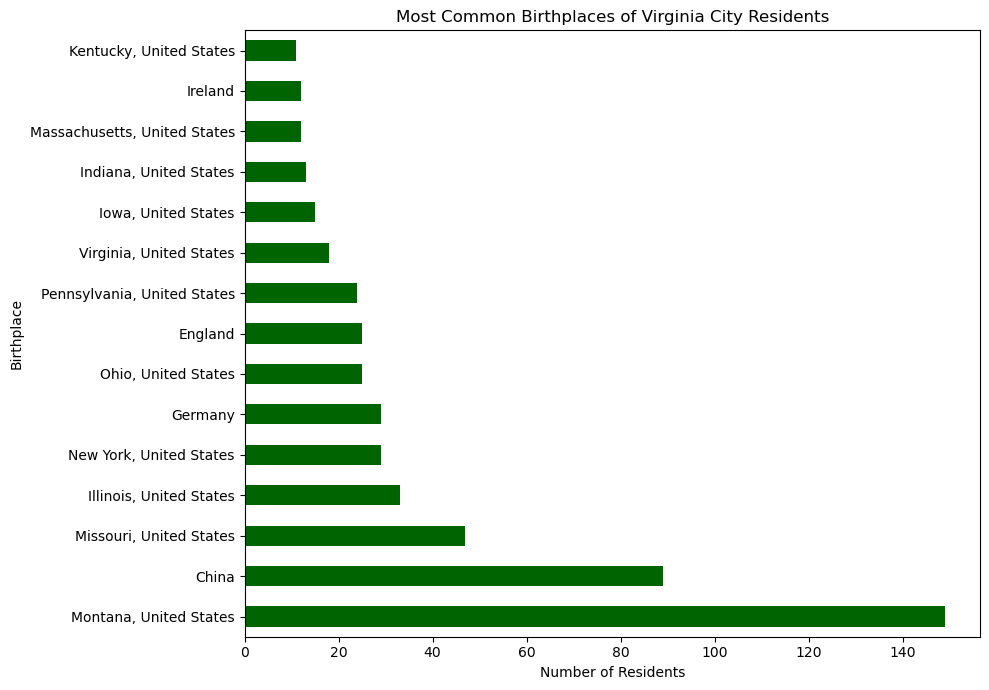

In [29]:
top_birthplaces = df["Birthplace"].value_counts().head(15)

top_birthplaces.plot(
    kind="barh",
    figsize=(10,7),
    color="darkgreen"
)

plt.title("Most Common Birthplaces of Virginia City Residents")
plt.xlabel("Number of Residents")

plt.tight_layout()

plt.show()

### Key Insight

Residents originated from numerous birthplaces, illustrating the migration patterns that fueled Virginia City's development. The diversity of birthplaces highlights the attraction of western mining communities to individuals seeking economic opportunity.



## Household Relationships

In [32]:
df["Relationship to Head of Household"].value_counts()

Relationship to Head of Household
Self              184
Other             127
Son               114
Daughter           96
Wife               85
Sister-in-law       4
Brother             4
Sister              3
Nephew              3
Mother-in-law       2
Brother-in-law      1
Mother              1
Grandmother         1
Name: count, dtype: int64

## Marital Status

In [33]:
df["Marital Status"].value_counts()

Marital Status
Single      425
Married     180
Widowed      13
Divorced      5
Name: count, dtype: int64

## Average Age by Occupation

In [36]:
occupation_summary = (
    df.groupby("Occupation")
      .agg(
          Average_Age=("Age_Clean", "mean"),
          Count=("Occupation", "count")
      )
      .sort_values("Count", ascending=False)
)

occupation_summary.head(20)

,Average_Age,Count
Occupation,,
Keeping House,34.717391,92
Placer Miner,36.264706,34
Cook,32.736842,19
Laborer,38.631579,19
Teamster,26.764706,17
Clerk In Store,26.666667,15
Stays At Home,27.857143,14
Quartz Miner,41.461538,13
Attends School,13.600000,10


## Sex Distribution

This section examines the distribution of residents by sex to better understand the demographic composition of Virginia City in 1880.

In [41]:
sex_counts = df["Sex"].value_counts()

sex_counts

Sex
Male      403
Female    222
Name: count, dtype: int64

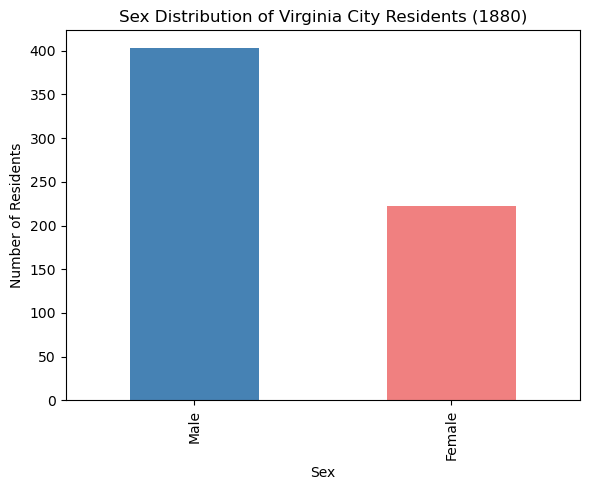

In [42]:
sex_counts.plot(
    kind="bar",
    figsize=(6,5),
    color=["steelblue", "lightcoral"]
)

plt.title("Sex Distribution of Virginia City Residents (1880)")
plt.xlabel("Sex")
plt.ylabel("Number of Residents")

plt.tight_layout()
plt.show()


### Key Insight

The population was predominantly male, reflecting the workforce demands of frontier mining communities. However, the presence of women and children indicates that Virginia City supported permanent families as well as individual laborers.

## Race Distribution

This section examines the racial composition of Virginia City in 1880.

In [43]:
race_counts = df["Race"].value_counts()

race_counts

Race
White      528
Chinese     91
Black        6
Name: count, dtype: int64

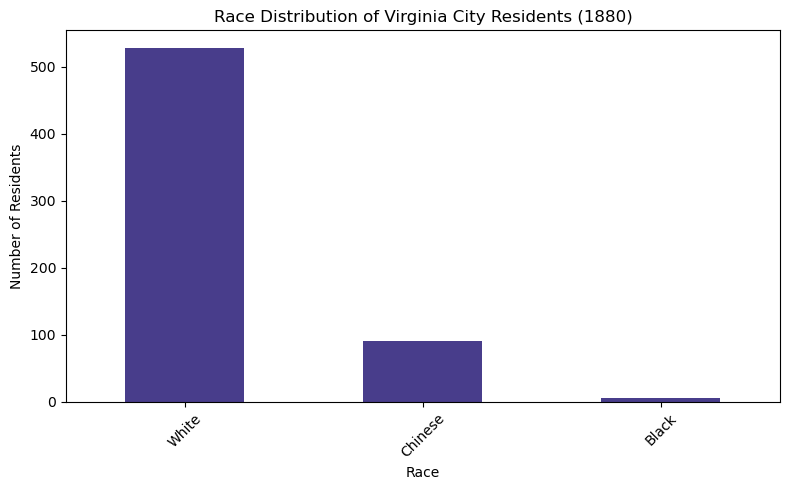

In [45]:
race_counts.plot(
    kind="bar",
    figsize=(8,5),
    color="darkslateblue"
)

plt.title("Race Distribution of Virginia City Residents (1880)")
plt.xlabel("Race")
plt.ylabel("Number of Residents")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Insight

The census indicates that one racial group comprised the majority of residents. While this reflects the demographic composition recorded in 1880, it also illustrates the limitations of historical census records in fully representing the diversity of frontier communities.


## Occupation by Sex

This analysis explores whether occupations differed between male and female residents.

In [46]:
occupation_sex = pd.crosstab(df["Occupation"], df["Sex"])

occupation_sex.head(20)

Sex,Female,Male
Occupation,,
Accountant,0,2
At School,2,1
Attending School,1,0
Attends School,3,7
Attends Stable,0,1
Baker,0,1
Bank Clerk,0,2
Banker,0,4
Barber,0,2


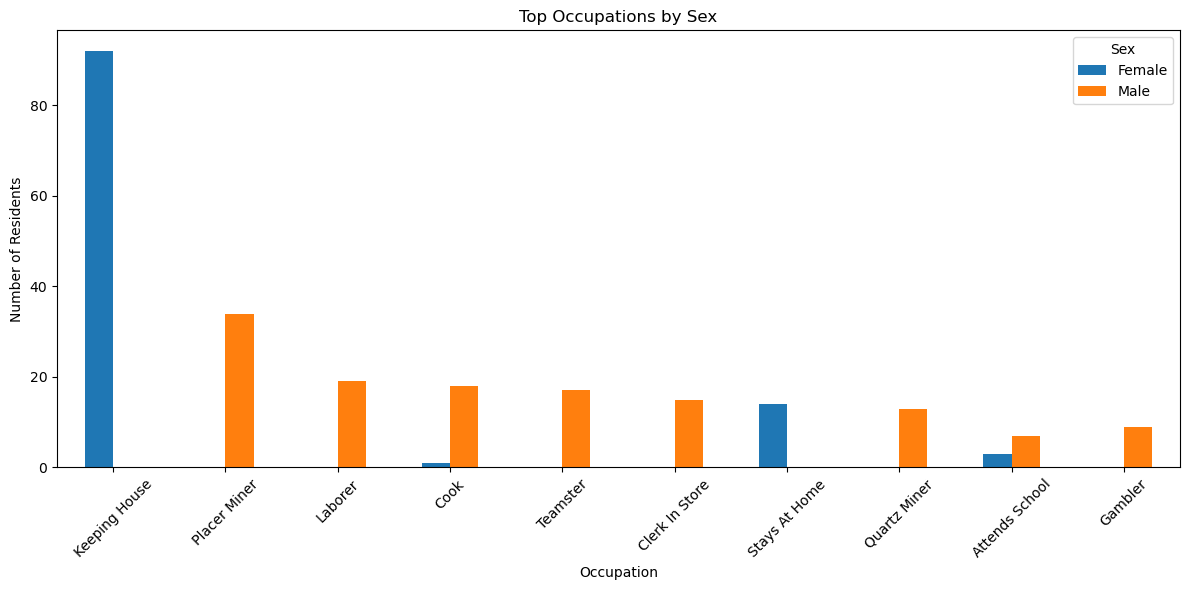

In [47]:
top_occupations = df["Occupation"].value_counts().head(10).index

occupation_sex_top = occupation_sex.loc[top_occupations]

occupation_sex_top.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top Occupations by Sex")
plt.xlabel("Occupation")
plt.ylabel("Number of Residents")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Insight

Occupational patterns differed between men and women, reflecting the social and economic roles commonly observed during the late nineteenth century. Male residents were concentrated in mining and skilled trades, while female occupations were generally associated with domestic work, education, or service industries.

## Relationship Between Age and Marital Status

This analysis explores the relationship between age and marital status to identify demographic patterns within Virginia City's population.

In [48]:
marital_age = (
    df.groupby("Marital Status")["Age_Clean"]
      .mean()
      .sort_values(ascending=False)
)

marital_age

Marital Status
Widowed     53.461538
Married     38.638889
Divorced    37.000000
Single      22.340476
Name: Age_Clean, dtype: float64

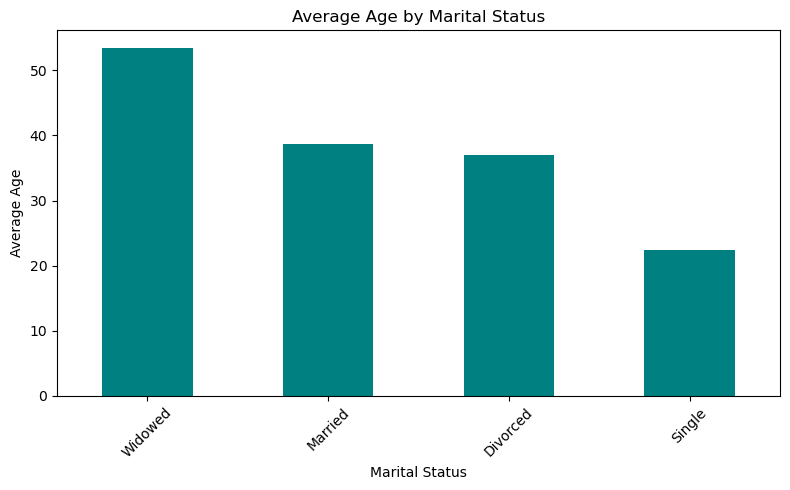

In [49]:
marital_age.plot(
    kind="bar",
    figsize=(8,5),
    color="teal"
)

plt.title("Average Age by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Average Age")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Insight

Average age varied across marital status categories, with widowed residents generally having the highest average age. This pattern is consistent with expected demographic trends, as widowhood typically occurs later in life.

## Birthplace by Occupation

In [50]:
top_birthplaces = df["Birthplace"].value_counts().head(5).index
top_occupations = df["Occupation"].value_counts().head(10).index

filtered = df[
    df["Birthplace"].isin(top_birthplaces) &
    df["Occupation"].isin(top_occupations)
]

birthplace_occupation = pd.crosstab(
    filtered["Birthplace"],
    filtered["Occupation"]
)

birthplace_occupation

Occupation,Attends School,Clerk In Store,Cook,Gambler,Keeping House,Laborer,Placer Miner,Quartz Miner,Stays At Home,Teamster
Birthplace,,,,,,,,,,
China,0,0,15,9,0,3,26,0,0,0
"Illinois, United States",0,1,0,0,7,2,1,0,2,0
"Missouri, United States",2,1,1,0,13,2,0,1,2,3
"Montana, United States",7,0,0,0,1,0,0,0,1,0
"New York, United States",0,1,1,0,4,0,1,2,0,0


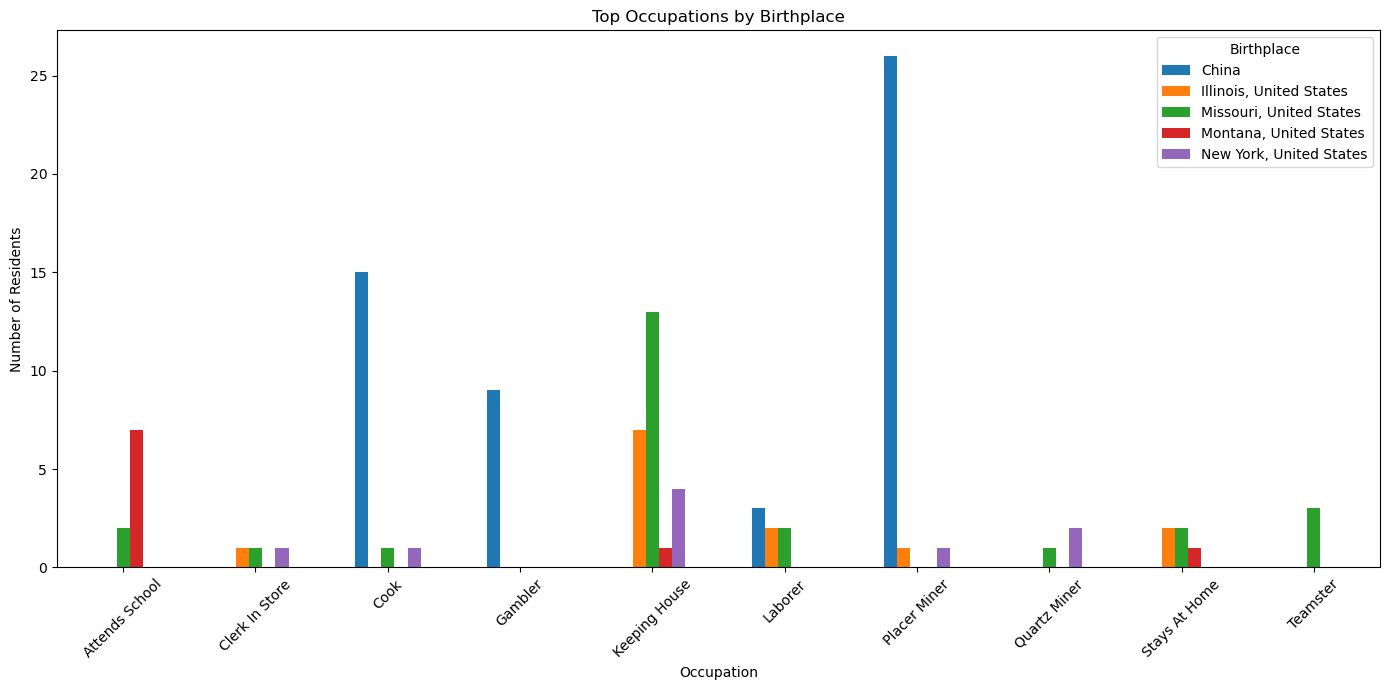

In [51]:
birthplace_occupation.T.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Top Occupations by Birthplace")
plt.xlabel("Occupation")
plt.ylabel("Number of Residents")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Insight

Comparing occupation with birthplace reveals how migration contributed to Virginia City's workforce. Certain occupations may have been associated with specific immigrant communities, illustrating the influence of migration on the town's economic development.

# Conclusions


This exploratory analysis demonstrates that historical census records can be effectively transformed into a structured dataset suitable for data science applications. Patterns in age, occupation, birthplace, household composition, and marital status provide insight into the demographic makeup of Virginia City during the late nineteenth century.

These findings establish the foundation for the second phase of this project, where the census is transformed into a social network to examine relationships between residents and reconstruct the community structure of Virginia City.